In [1]:
import numpy as np
import miepython as mie
import matplotlib.pyplot as plt

def convert_volume_to_intensity_rayleigh(diameters_nm, volume_dist):
    """
    Converts a volume-weighted PSD to an intensity-weighted PSD using
    the Rayleigh approximation (I ~ d^6).

    Args:
        diameters_nm (np.ndarray): Array of particle diameters in nm.
        volume_dist (np.ndarray): Corresponding volume-weighted distribution values.

    Returns:
        np.ndarray: The normalized intensity-weighted distribution.
    """
    # Weighting factor is d^6 / d^3 = d^3
    weighting_factor = diameters_nm**3
    
    # Apply the weighting factor
    unnormalized_intensity_dist = volume_dist * weighting_factor
    
    # Normalize the final distribution to sum to 1
    total_intensity = np.sum(unnormalized_intensity_dist)
    if total_intensity == 0:
        return unnormalized_intensity_dist
        
    return unnormalized_intensity_dist / total_intensity


def mie_intensity_weighting_factor(
    diameters_nm, 
    theta_deg,
    m_particle, 
    n_medium, 
    wavelength_nm, 
):
    """
    Converts a volume-weighted PSD to an intensity-weighted PSD using
    full Mie theory for a specific angle (ideal for DLS).
    """
    # Calculate constant values
    m_relative = m_particle / n_medium
    mu = np.cos(np.deg2rad(theta_deg))
    
    # Calculate the angle-specific Mie scattering intensity for each diameter
    mie_intensity_at_angle = []
    for d in diameters_nm:
        if d == 0:
            mie_intensity_at_angle.append(0)
            continue
        r = d / 2
        x = 2 * np.pi * r * n_medium / wavelength_nm
        s1, s2 = mie.S1_S2(m_relative, x, mu)
        
        # Intensity for unpolarized light is the average of the two polarizations
        intensity = 0.5 * (np.abs(s1)**2 + np.abs(s2)**2)
        mie_intensity_at_angle.append(intensity)
    
    mie_intensity_at_angle = np.array(mie_intensity_at_angle).flatten()
    
    # --- THE FIX IS HERE ---
    # The weighting factor should MULTIPLY by d^3, not divide.
    weighting_factor = mie_intensity_at_angle * (diameters_nm**3)

    return weighting_factor

def volume2intensity(
        volume_dist,
        weighting_factor,
):
    # Apply the weighting factor
    unnormalized_intensity_dist = volume_dist * weighting_factor
    
    # Normalize the final distribution to sum to 1
    total_intensity = np.sum(unnormalized_intensity_dist)
    if total_intensity == 0:
        return unnormalized_intensity_dist
        
    return unnormalized_intensity_dist / total_intensity


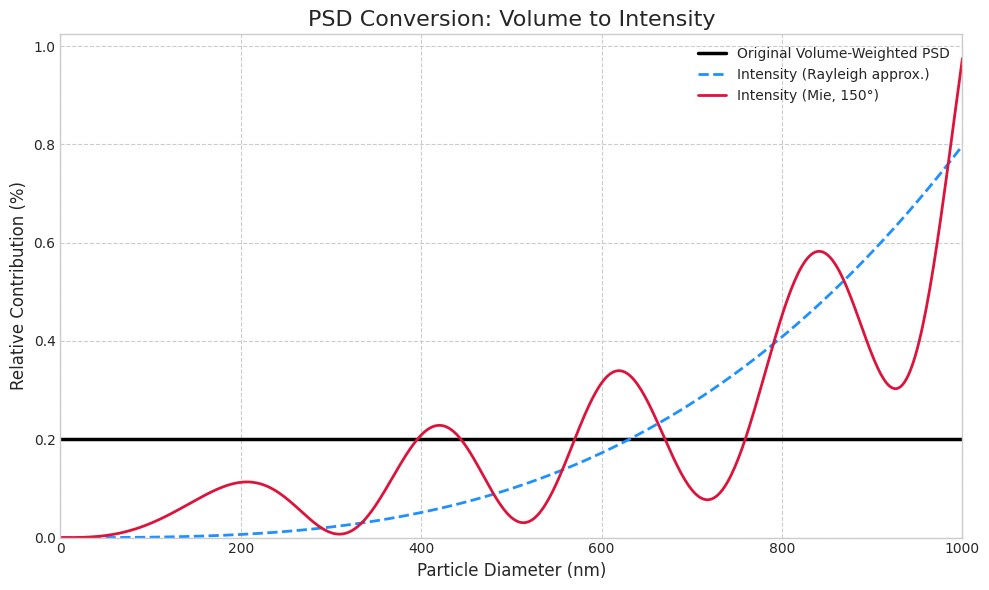

In [2]:
# --- 1. Define Physical Parameters for Mie Calculation ---
m_particle = 1.59      # Polystyrene
# m_particle = 1.7
n_medium = 1.33        # Water
wavelength_nm = 633    # HeNe laser
theta_deg = 150        # DLS backscatter angle

# --- 2. Create a Sample Volume-Weighted PSD ---
# This simulates a bimodal distribution with peaks at 80 nm and 400 nm
diameters_nm = np.linspace(1, 1000, 500)
peak1 = 0.7 * np.exp(-((diameters_nm - 80)**2) / (2 * 20**2))
peak2 = 0.3 * np.exp(-((diameters_nm - 700)**2) / (2 * 50**2))
volume_dist = peak1 + peak2

volume_dist = np.ones_like(volume_dist)

# Normalize the starting distribution
volume_dist /= np.sum(volume_dist)

# --- 3. Perform the Conversions ---
intensity_dist_rayleigh = convert_volume_to_intensity_rayleigh(diameters_nm, volume_dist)
# intensity_dist_mie = convert_volume_to_intensity_mie(
#     diameters_nm, 
#     volume_dist, 
#     m_particle, 
#     n_medium, 
#     wavelength_nm, 
#     theta_deg
# )
mie_weight_factor = mie_intensity_weighting_factor(
    diameters_nm, 
    theta_deg,
    m_particle, 
    n_medium, 
    wavelength_nm, 
)

intensity_dist_mie = volume2intensity(
    volume_dist,
    mie_weight_factor,
)

# --- 4. Plot the Results for Comparison ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(diameters_nm, volume_dist * 100, lw=2.5, color='black', label='Original Volume-Weighted PSD')
ax.plot(diameters_nm, intensity_dist_rayleigh * 100, lw=2, ls='--', color='dodgerblue', label='Intensity (Rayleigh approx.)')
# ax.plot(diameters_nm, intensity_dist_mie * 100, lw=2, ls='-', color='crimson', label=f'Intensity (Mie, {theta_deg}°)')
ax.plot(diameters_nm, intensity_dist_mie * 100, lw=2, ls='-', color='crimson', label=f'Intensity (Mie, {theta_deg}°)')

ax.set_xlabel("Particle Diameter (nm)", fontsize=12)
ax.set_ylabel("Relative Contribution (%)", fontsize=12)
ax.set_title("PSD Conversion: Volume to Intensity", fontsize=16)
ax.legend()
ax.grid(True, which="both", ls="--")
ax.set_xlim(0, 1000)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

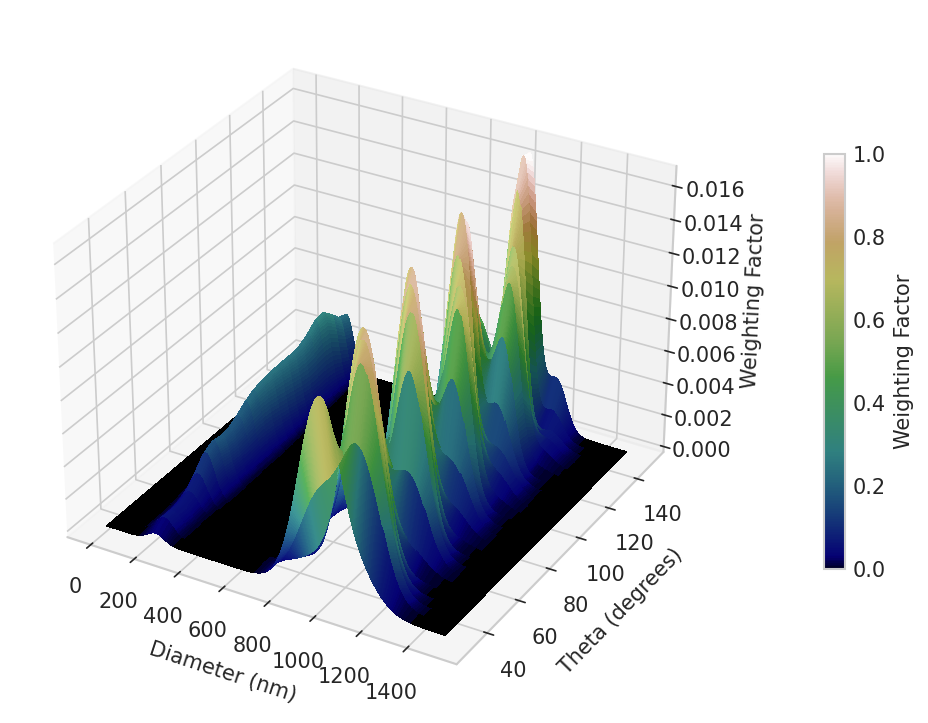

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cbook, cm
from matplotlib.colors import LightSource

# --- 1. Define Physical Parameters for Mie Calculation ---
m_particle = 1.59      # Polystyrene
# m_particle = 1.7
n_medium = 1.33        # Water
wavelength_nm = 633    # HeNe laser
# theta_deg = 150        # DLS backscatter angle
# theta = np.arange(30., 151, 5)
theta = np.arange(30., 151, 5)

# --- 2. Create a Sample Volume-Weighted PSD ---
# This simulates a bimodal distribution with peaks at 80 nm and 400 nm
diameters_nm = np.linspace(1, 1500, 500)
peak1 = 0.7 * np.exp(-((diameters_nm - 200)**2) / (2 * 40**2))
peak2 = 0.3 * np.exp(-((diameters_nm - 1000)**2) / (2 * 100**2))
volume_dist = peak1 + peak2

# volume_dist = np.ones_like(volume_dist)

# Normalize the starting distribution
volume_dist /= np.sum(volume_dist)

# volume_dist = np.ones_like(volume_dist)


weight_factors = []
for theta_deg in theta:
    weight_angle = mie_intensity_weighting_factor(
        diameters_nm, 
        theta_deg,
        m_particle, 
        n_medium, 
        wavelength_nm, 
    )

    intensity_dist_mie = volume2intensity(
        volume_dist,
        weight_angle,
    )
    weight_factors.append(intensity_dist_mie)


weight_factor_matrix = np.array(weight_factors)

# Load and format data
X, Y = np.meshgrid(diameters_nm, theta)
Z = weight_factor_matrix



# --- Your original code begins here ---
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), figsize=(10, 6), dpi=150)

ls = LightSource(270, 45)
rgb = ls.shade(Z, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')

# --- SOLUTION: Create a mappable object for the colorbar ---
# 1. Normalize the data to the range of your z-axis
# 2. Create the mappable object using the same colormap
mappable = cm.ScalarMappable(cmap=cm.gist_earth)

# Plot the surface using your pre-calculated RGB values
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, facecolors=rgb,
                       linewidth=0, antialiased=False, shade=False)

# 3. Add the colorbar to the figure, linking it to the mappable
cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Weighting Factor')

ax.set_xlabel("Diameter (nm)")
ax.set_ylabel("Theta (degrees)")
ax.set_zlabel("Weighting Factor")

plt.show()

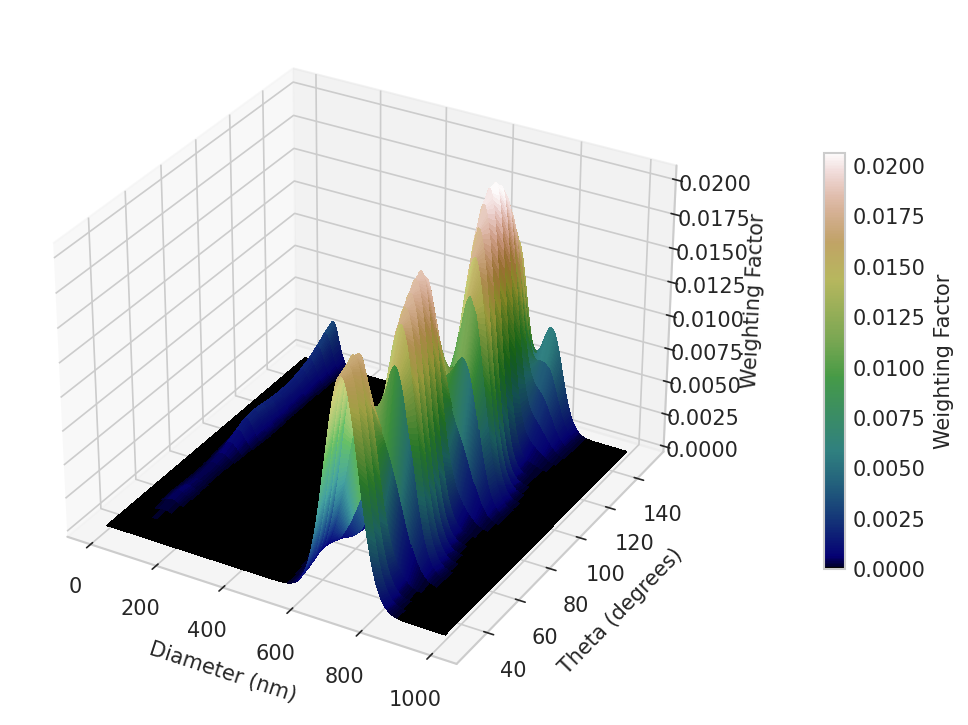

In [55]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LightSource, Normalize

# # --- Create dummy data to make the script runnable ---
# # In your code, you would use your actual x, y, and z data.
# x = np.arange(0, 1000, 20)
# y = np.arange(40, 150, 2)
# X, Y = np.meshgrid(x, y)
# Z = (np.sin(X/100) * np.cos(Y/10))**2 * 0.02

X, Y, Z = x, y, z

# --- Your original code begins here ---
fig, ax = plt.subplots(subplot_kw=dict(projection='3d'), figsize=(10, 6), dpi=150)

ls = LightSource(270, 45)
rgb = ls.shade(Z, cmap=cm.gist_earth, vert_exag=0.1, blend_mode='soft')

# --- SOLUTION: Create a mappable object for the colorbar ---
# 1. Normalize the data to the range of your z-axis
norm = Normalize(vmin=Z.min(), vmax=Z.max())
# 2. Create the mappable object using the same colormap
mappable = cm.ScalarMappable(norm=norm, cmap=cm.gist_earth)

# Plot the surface using your pre-calculated RGB values
surf = ax.plot_surface(X, Y, Z, rstride=1, cstride=1, facecolors=rgb,
                       linewidth=0, antialiased=False, shade=False)

# 3. Add the colorbar to the figure, linking it to the mappable
cbar = fig.colorbar(mappable, ax=ax, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Weighting Factor')

ax.set_xlabel("Diameter (nm)")
ax.set_ylabel("Theta (degrees)")
ax.set_zlabel("Weighting Factor")

plt.show()